In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [58]:
df = pd.read_csv('solar.csv')

In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [26]:
segmentation_data = df[
    [
        "distance_from_darab_km",
        "property_type",
        "usage_purpose",
        "electricity_access",
        "lead_source",
        "required_appliances",
        "estimated_daily_energy_need_kwh",
        "quoted_price_m_toman"
    ]
].copy()

In [27]:
segmentation_data.isna().sum()

distance_from_darab_km              0
property_type                       0
usage_purpose                      12
electricity_access                  0
lead_source                        12
required_appliances                 0
estimated_daily_energy_need_kwh     0
quoted_price_m_toman                0
dtype: int64

In [28]:
segmentation_data["usage_purpose"] = segmentation_data["usage_purpose"].fillna(segmentation_data["usage_purpose"].mode()[0])
segmentation_data["lead_source"] = segmentation_data["lead_source"].fillna(segmentation_data["lead_source"].mode()[0])

In [30]:
segmentation_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   distance_from_darab_km           300 non-null    float64
 1   property_type                    300 non-null    object 
 2   usage_purpose                    300 non-null    object 
 3   electricity_access               300 non-null    object 
 4   lead_source                      300 non-null    object 
 5   required_appliances              300 non-null    object 
 6   estimated_daily_energy_need_kwh  300 non-null    float64
 7   quoted_price_m_toman             300 non-null    float64
dtypes: float64(3), object(5)
memory usage: 18.9+ KB


In [31]:
numeric_cols = [
    "distance_from_darab_km",
    "estimated_daily_energy_need_kwh",
    "quoted_price_m_toman"
]

categorical_cols = [
    "property_type",
    "usage_purpose",
    "electricity_access",
    "lead_source",
    "required_appliances"
]

In [32]:
scaler = StandardScaler()

numeric_scaled = pd.DataFrame(scaler.fit_transform(segmentation_data[numeric_cols]),columns=numeric_cols)

In [33]:
categorical_encoded = pd.get_dummies(segmentation_data[categorical_cols])

In [34]:
segmentation_scaled = pd.concat([numeric_scaled, categorical_encoded],axis=1)

In [35]:

inertias = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k,init='k-means++',n_init=10,random_state=42)
    cluster_labels= kmeans.fit(segmentation_scaled)
    inertias.append(kmeans.inertia_)

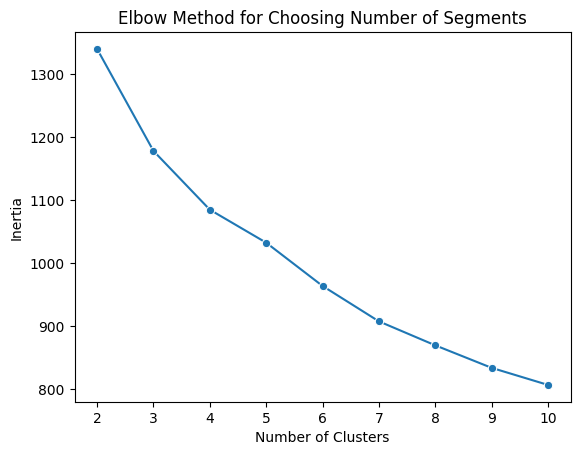

In [36]:
sns.lineplot(x=range(2, 11), y=inertias, marker="o")

plt.title("Elbow Method for Choosing Number of Segments")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [37]:
from sklearn.metrics import silhouette_score

In [38]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(segmentation_scaled)
    score = silhouette_score(segmentation_scaled, cluster_labels)
    silhouette_scores.append(score)

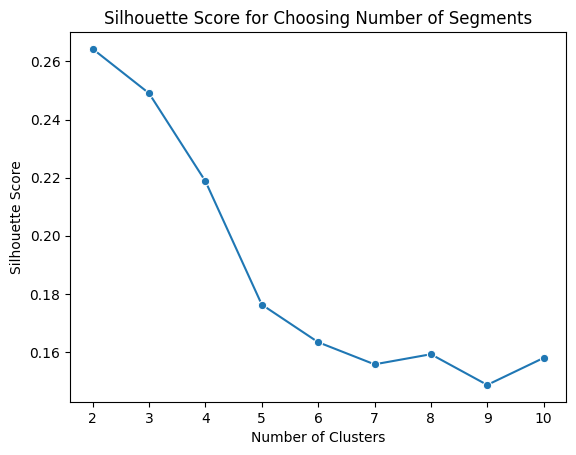

In [39]:
sns.lineplot(x=range(2, 11), y=silhouette_scores, marker="o")

plt.title("Silhouette Score for Choosing Number of Segments")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

K-Means was initially tested for customer segmentation. However, the elbow method did not reveal a clear optimal number of clusters, and the silhouette scores remained relatively low across different values of (k), indicating weak cluster separation. In addition, the dataset contained a combination of numerical and categorical variables, making K-Means less suitable for this problem. Therefore, K-Prototypes was selected as a more appropriate clustering algorithm for handling mixed data types.

#The purchased variable was excluded from the clustering process to prevent target leakage and was used only after segmentation to analyze and interpret the purchase behavior of each customer segment.

In [48]:
!pip install kmodes


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
from kmodes.kprototypes import KPrototypes

In [61]:
segmentation_data = df[
    [
        "distance_from_darab_km",
        "property_type",
        "usage_purpose",
        "electricity_access",
        "lead_source",
        "required_appliances",
        "estimated_daily_energy_need_kwh",
        "quoted_price_m_toman"
    ]
].copy()

In [62]:
segmentation_data["usage_purpose"] = segmentation_data["usage_purpose"].fillna(segmentation_data["usage_purpose"].mode()[0])
segmentation_data["lead_source"] = segmentation_data["lead_source"].fillna(segmentation_data["lead_source"].mode()[0])

In [63]:
numeric_cols = [
    "distance_from_darab_km",
    "estimated_daily_energy_need_kwh",
    "quoted_price_m_toman"
]

categorical_cols = [
    "property_type",
    "usage_purpose",
    "electricity_access",
    "lead_source",
    "required_appliances"
]

In [64]:
scaler = StandardScaler()

segmentation_data_scaled = segmentation_data.copy()

segmentation_data_scaled[numeric_cols] = scaler.fit_transform(segmentation_data_scaled[numeric_cols])

In [65]:
categorical_indices = [1, 2, 3, 4, 5]

In [66]:
segmentation_data_scaled.columns

Index(['distance_from_darab_km', 'property_type', 'usage_purpose',
       'electricity_access', 'lead_source', 'required_appliances',
       'estimated_daily_energy_need_kwh', 'quoted_price_m_toman'],
      dtype='object')

In [67]:
costs = []

for k in range(2, 8):
    kproto = KPrototypes(
        n_clusters=k,
        init="Cao",
        n_init=5,
        random_state=42
    )
    
    clusters = kproto.fit_predict(
        segmentation_data_scaled,
        categorical=categorical_indices
    )
    
    costs.append(kproto.cost_)

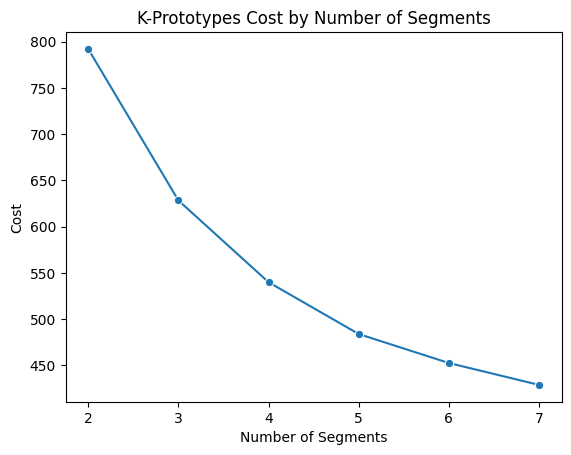

In [68]:
sns.lineplot(x=range(2, 8), y=costs, marker="o")

plt.title("K-Prototypes Cost by Number of Segments")
plt.xlabel("Number of Segments")
plt.ylabel("Cost")
plt.show()

In [69]:
kproto = KPrototypes(
    n_clusters=4,
    init="Cao",
    n_init=5,
    random_state=42
)

df["customer_segment"] = kproto.fit_predict(
    segmentation_data_scaled,
    categorical=categorical_indices
)


In [70]:
df["customer_segment"].value_counts()

customer_segment
0    132
1    105
3     38
2     25
Name: count, dtype: int64

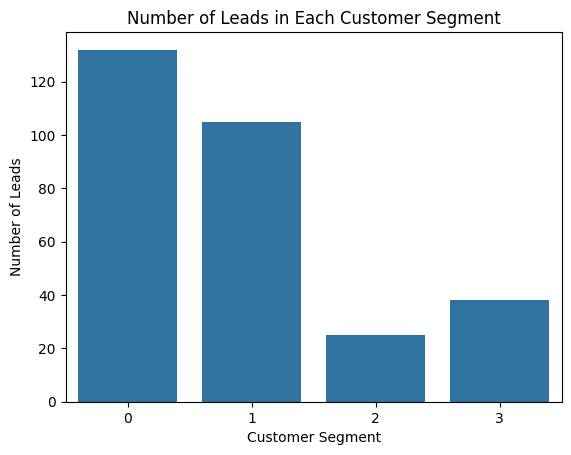

In [71]:
sns.countplot(data=df, x="customer_segment")

plt.title("Number of Leads in Each Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Leads")
plt.show()

In [72]:
pd.crosstab(
    df["customer_segment"],
    df["property_type"],
    normalize="index"
).round(2) * 100

property_type,farm,garden_house,rural_house
customer_segment,,,
0,71.0,17.0,11.0
1,10.0,61.0,30.0
2,8.0,68.0,24.0
3,68.0,18.0,13.0


In [73]:
pd.crosstab(
    df["customer_segment"],
    df["usage_purpose"],
    normalize="index"
).round(2) * 100

usage_purpose,agriculture,mixed_use,primary_residence,seasonal_garden
customer_segment,,,,
0,57.0,24.0,6.0,12.0
1,7.0,17.0,19.0,56.0
2,8.0,21.0,17.0,54.0
3,47.0,32.0,8.0,13.0


In [74]:
pd.crosstab(
    df["customer_segment"],
    df["electricity_access"],
    normalize="index"
).round(2) * 100

electricity_access,none,unstable
customer_segment,,
0,70.0,30.0
1,66.0,34.0
2,60.0,40.0
3,66.0,34.0


In [74]:
pd.crosstab(
    df["customer_segment"],
    df["required_appliances"],
    normalize="index"
).round(2) * 100

required_appliances,"AC,fridge","AC,fridge,lights",lights,"lights,TV","lights,fridge","lights,fridge,TV",pump,"pump,AC","pump,fridge","pump,lights"
customer_segment,,,,,,,,,,
0,2.0,0.0,0.0,0.0,49.0,46.0,2.0,0.0,0.0,0.0
1,0.0,0.0,33.0,51.0,16.0,0.0,0.0,0.0,0.0,0.0
2,14.0,7.0,0.0,0.0,0.0,0.0,30.0,0.0,13.0,36.0
3,2.0,13.0,0.0,0.0,0.0,0.0,3.0,30.0,27.0,25.0


In [75]:
df.head()

,lead_id,village,distance_from_darab_km,property_type,usage_purpose,electricity_access,lead_source,required_appliances,estimated_daily_energy_need_kwh,quoted_price_m_toman,purchased,customer_segment
0,L0001,Hasan Abad,14.9,garden_house,mixed_use,none,referral,"pump,lights",10.0,628.7,1,0
1,L0002,Madavan,32.1,rural_house,seasonal_garden,none,referral,"lights,TV",2.5,151.0,1,1
2,L0003,Layzangan,82.1,garden_house,mixed_use,none,referral,"lights,fridge,TV",4.5,284.1,0,2
3,L0004,Dabiran,70.6,garden_house,seasonal_garden,unstable,local_ad,"lights,fridge",4.7,286.8,0,2
4,L0005,Jannat Shahr,24.8,garden_house,mixed_use,unstable,instagram,"lights,fridge",5.1,282.2,1,1


In [76]:
df.groupby('customer_segment')['estimated_daily_energy_need_kwh'].mean()

customer_segment
0    9.982576
1    4.228571
2    4.068000
3    9.647368
Name: estimated_daily_energy_need_kwh, dtype: float64

In [77]:
df.groupby('customer_segment')['quoted_price_m_toman'].mean()

customer_segment
0    617.428788
1    258.607619
2    260.652000
3    594.850000
Name: quoted_price_m_toman, dtype: float64

In [86]:
df.groupby('customer_segment')['purchased'].mean()*100

customer_segment
0    52.873563
1    44.186047
2    61.682243
3    77.777778
Name: purchased, dtype: float64

In [78]:
df.groupby("customer_segment")[[
    "estimated_daily_energy_need_kwh",
    "quoted_price_m_toman",
    "purchased"
]].mean()

,estimated_daily_energy_need_kwh,quoted_price_m_toman,purchased
customer_segment,,,
0,9.982576,617.428788,0.674242
1,4.228571,258.607619,0.514286
2,4.068000,260.652000,0.440000
3,9.647368,594.850000,0.684211


In [79]:
segment_summary = df.groupby("customer_segment").agg(
    lead_count=("lead_id", "count"),
    avg_distance_km=("distance_from_darab_km", "mean"),
    avg_energy_need_kwh=("estimated_daily_energy_need_kwh", "mean"),
    avg_quoted_price=("quoted_price_m_toman", "mean"),
    purchase_rate=("purchased", "mean")
).reset_index()

segment_summary["purchase_rate"] = segment_summary["purchase_rate"] * 100

segment_summary.round(1)

,customer_segment,lead_count,avg_distance_km,avg_energy_need_kwh,avg_quoted_price,purchase_rate
0,0,132,15.8,10.0,617.4,67.4
1,1,105,17.7,4.2,258.6,51.4
2,2,25,69.9,4.1,260.7,44.0
3,3,38,63.2,9.6,594.8,68.4


# Customer Segmentation

## Objective

The objective of this section is to group customer leads into meaningful segments based on their characteristics, energy needs, property type, usage purpose, electricity access, lead source, quoted price, and distance from Darab.

Unlike the purchase prediction model, segmentation is an unsupervised learning task. Therefore, the target variable `purchased` was not used during clustering. The goal was not to predict purchase directly, but to understand different types of leads and support better sales prioritization.

After the segments were created, the `purchased` column was used only for interpretation. This helped evaluate which customer groups had higher or lower actual purchase rates.

## Why K-Prototypes Was Used

The dataset contains both numerical and categorical variables. Numerical variables include distance from Darab, estimated daily energy need, and quoted price. Categorical variables include property type, usage purpose, electricity access, lead source, and required appliances.

K-Means was first considered as a baseline clustering method. However, K-Means works best with numerical data and requires one-hot encoding for categorical variables. Since this project includes many categorical business features, K-Means was not the most suitable method for the final segmentation.

K-Prototypes was selected because it can handle mixed data types. It combines numerical distance for continuous variables with categorical matching for text-based variables. This makes it more appropriate for customer segmentation in this project.

## Feature Selection for Segmentation

The following variables were used for customer segmentation:

* `distance_from_darab_km`
* `estimated_daily_energy_need_kwh`
* `quoted_price_m_toman`
* `property_type`
* `usage_purpose`
* `electricity_access`
* `lead_source`
* `required_appliances`

The `purchased` column was excluded from the clustering process to avoid using the sales outcome as an input. This keeps the segmentation independent from the target variable and allows the purchase rate to be used later as a business interpretation metric.

## Missing Value Treatment

Missing values in categorical variables were filled using the most frequent value of each column. This approach was chosen instead of creating an `Unknown` category, because an artificial unknown group could influence the clustering result and create less meaningful segments.

Using the mode keeps the dataset simple and avoids giving too much importance to missing values in a relatively small project dataset.

## Scaling Numerical Features

Numerical variables were scaled before applying K-Prototypes. This was important because the numerical features have different units and ranges. For example, quoted price is measured in million toman, while distance is measured in kilometers and energy need is measured in kWh per day.

Without scaling, variables with larger numerical ranges could dominate the clustering process. Standard scaling was applied only to the numerical variables, while categorical variables were kept in their original categorical form for K-Prototypes.

## Number of Segments

Different values of `k` were tested using the K-Prototypes cost value. The final segmentation was created using four customer segments. Four segments were selected because they provided a clear and interpretable business structure without making the segmentation too complex.

The four resulting customer segments were:

* Segment 0: Core Agricultural Household-Energy Leads
* Segment 1: Nearby Seasonal Basic-Energy Leads
* Segment 2: Remote Seasonal Pump-Light Leads
* Segment 3: Remote High-Need Pump System Leads

## Segment Summary

The segmentation results showed that customers are mainly separated by energy need, property type, usage purpose, appliance requirements, and distance from Darab.

Segment 0 had 132 leads, an average distance of 15.8 km, an average daily energy need of 10.0 kWh, an average quoted price of 617.4 million toman, and a purchase rate of 67.4%.

Segment 1 had 105 leads, an average distance of 17.7 km, an average daily energy need of 4.2 kWh, an average quoted price of 258.6 million toman, and a purchase rate of 51.4%.

Segment 2 had 25 leads, an average distance of 69.9 km, an average daily energy need of 4.1 kWh, an average quoted price of 260.7 million toman, and a purchase rate of 44.0%.

Segment 3 had 38 leads, an average distance of 63.2 km, an average daily energy need of 9.6 kWh, an average quoted price of 594.8 million toman, and a purchase rate of 68.4%.

## Segment 0: Core Agricultural Household-Energy Leads

Segment 0 is the largest customer group and represents one of the most valuable lead segments. This segment is mainly composed of farm properties and agriculture-related use cases. Around 71% of this segment consists of farms, and 57% of the leads are related to agriculture use.

Most leads in this segment have no electricity access, and the average energy need is relatively high. The most common appliance needs are `lights,fridge` and `lights,fridge,TV`. This suggests that these customers need practical electricity for daily farm-related activities, storage, lighting, and basic household use on agricultural properties.

This segment has a high purchase rate of 67.4%, showing strong market potential. From a sales perspective, this segment should be treated as a high-priority group because it is large, practical, and commercially valuable.

## Segment 1: Nearby Seasonal Basic-Energy Leads

Segment 1 mainly consists of garden houses and seasonal garden use cases located relatively close to Darab. Around 61% of this segment consists of garden houses, and 56% of the leads are related to seasonal garden use.

The appliance needs in this segment are mostly basic, especially `lights` and `lights,TV`. The average energy need and quoted price are lower compared with the agricultural high-need segments.

This segment has a moderate purchase rate of 51.4%. These customers may still be valuable, but their energy need is less urgent and more seasonal. They may require simpler solar packages, more explanation, and longer follow-up before purchase.

## Segment 2: Remote Seasonal Pump-Light Leads

Segment 2 is a smaller segment with only 25 leads. It is mainly composed of remote garden house and seasonal garden users. Around 68% of this segment consists of garden houses, and 54% of the leads are related to seasonal garden use.

Although this segment includes pump-related appliance needs such as `pump`, `pump,lights`, and `pump,fridge`, the average daily energy need remains relatively low. This suggests that the energy need is practical but limited, possibly linked to occasional or seasonal use.

This segment has the lowest purchase rate at 44.0%. The combination of long distance from Darab, seasonal use, and relatively low energy demand makes this segment a lower sales priority. However, these leads should not be ignored completely, especially when pump needs indicate practical use.

## Segment 3: Remote High-Need Pump System Leads

Segment 3 is a smaller but highly valuable customer group. Although these leads are located far from Darab, they show high energy needs, high quoted prices, and the highest purchase rate among all segments.

This segment is mainly composed of farms and agriculture or mixed-use properties. Around 68% of the leads are farms, 47% are agriculture-related, and 32% are mixed-use. Appliance needs are strongly pump-related, including `pump,AC`, `pump,fridge`, and `pump,lights`.

The purchase rate of this segment is 68.4%, which is the highest among all groups. This shows that distance alone should not be used as a negative filter in sales prioritization. If a remote lead has strong practical energy needs, especially pump-related needs, it can still have very high purchase potential.

## Business Interpretation

The segmentation results show that customer value is mainly driven by practical energy need and usage purpose, not by distance alone. Segment 3 is far from Darab but has the highest purchase rate because the leads have strong farm and pump-related energy needs. In contrast, Segment 2 is also far from Darab but has the lowest purchase rate because the leads are more seasonal and have lower average energy needs.

This means that distance should mainly be considered as a logistics and installation factor, rather than a direct indicator of purchase likelihood.

The strongest customer groups are high-need farm and agriculture-related leads. Segment 3 has the strongest purchase potential per lead, while Segment 0 represents the largest high-value customer base.

## Sales Priority Based on Segments

The recommended sales priority is:

1. Segment 3: Remote High-Need Pump System Leads
2. Segment 0: Core Agricultural Household-Energy Leads
3. Segment 1: Nearby Seasonal Basic-Energy Leads
4. Segment 2: Remote Seasonal Pump-Light Leads

Segment 3 should receive fast follow-up because it has the highest purchase rate, high quoted prices, and strong practical energy needs. Segment 0 should also be prioritized because it is the largest high-value group and represents the core market for rural solar adoption.

Segment 1 can be targeted with simpler and lower-cost solar packages. Segment 2 should be treated with more caution because it has the lowest purchase rate, but pump-related needs may still create some sales opportunities.

## Key Insight

The main insight from the segmentation analysis is that purchase potential is not determined by distance alone. Leads with strong agricultural, farm-related, or pump-related energy needs can be valuable even when they are located far from Darab.

For this reason, the sales team should prioritize leads based on the combination of energy need, property type, usage purpose, and appliance requirements, rather than using distance as the main filtering criterion.

## Limitation

The segmentation analysis is based on a project dataset designed around a rural solar energy lead scoring business case. Therefore, the results should be interpreted as a portfolio-level decision-support exercise.

Also, Segment 2 contains only 25 leads, so its interpretation should be treated with more caution compared with larger segments.

## Conclusion

Overall, the segmentation analysis helped translate customer data into practical sales groups. These segments can support targeted follow-up strategies, better package design, and more efficient prioritization of rural solar leads.
